# Exploratory Data Analysis

## Imports Librairies

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from emotion_recognition.params import DATA_DIR, EMOTIONS_CLASSES
from emotion_recognition.src.data import load_data

### Variables

In [3]:
TRAIN_PATH = DATA_DIR/'train'
TEST_PATH  = DATA_DIR/'test'
RMV = '.DS_Store'

## Exploration

### Number of images per emotion

In [6]:
print('|' + '-' * 50 + '|')
print(f"{'|'} {'Number of images per class':>36} {'|':>13}")
print('|' + '-' * 50 + '|')
print(f"{'| Emotion':<12} {'|   Train files':<15}   | {'Test files':>14} {'|':>4}")
print('|' + '-' * 50 + '|')
for trn, test in zip(os.listdir(TRAIN_PATH), os.listdir(TEST_PATH)):
    if trn != RMV or test != RMV:
        nb_trn  = len(os.listdir(TRAIN_PATH/trn))
        nb_test = len(os.listdir(TEST_PATH/test))
        print(f"| {trn:<10} {f'| {nb_trn:>10}'} {'|':>6} {f'{nb_test:>11}'} {'|':>7}")
print('|' + '-' * 50 + '|')

|--------------------------------------------------|
|           Number of images per class             |
|--------------------------------------------------|
| Emotion    |   Train files   |     Test files    |
|--------------------------------------------------|
| happy      |       7215      |        1774       |
| sad        |       4830      |        1247       |
| fear       |       4097      |        1024       |
| surprise   |       3171      |         831       |
| neutral    |       4965      |        1233       |
| angry      |       3995      |         958       |
| disgust    |        436      |         111       |
|--------------------------------------------------|


### Total number of train and test images

In [18]:
total_trn  = []
total_test = []

for trn, test in zip(os.listdir(TRAIN_PATH), os.listdir(TEST_PATH)):
    if trn != RMV or test != RMV:
        nb_trn  = len(os.listdir(TRAIN_PATH/trn))
        nb_test = len(os.listdir(TEST_PATH/test))
        total_trn.append(nb_trn)
        total_test.append(nb_test)

sum_trn  = np.sum(total_trn)
sum_test = np.sum(total_test)

print(f'Number of images in the training dataset: {sum_trn}')
print(f'Number of images in the test dataset: {sum_test}')

Number of images in the training dataset: 28709
Number of images in the test dataset: 7178


### Percentage per class

In [8]:
print('|' + '-' * 50 + '|')
print(f"{'|'} {'Percentage of images per class':>38} {'|':>11}")
print('|' + '-' * 50 + '|')
print(f"{'| Emotion':<12} {'|   Train files':<15}   | {'Test files':>14} {'|':>4}")
print('|' + '-' * 50 + '|')
for trn, test in zip(os.listdir(TRAIN_PATH), os.listdir(TEST_PATH)):
    if trn != RMV or test != RMV:
        prc_trn  = (len(os.listdir(TRAIN_PATH/trn)) / sum_trn) *100
        prc_test = (len(os.listdir(TEST_PATH/test)) / sum_test) *100
        print(f"| {trn:<10} {f'| {round(prc_trn, 2):>10}%'} {'|':>5} {f'{round(prc_test, 2):>10}%'} {'|':>7}")
print('|' + '-' * 50 + '|')

|--------------------------------------------------|
|         Percentage of images per class           |
|--------------------------------------------------|
| Emotion    |   Train files   |     Test files    |
|--------------------------------------------------|
| happy      |      25.13%     |      24.71%       |
| sad        |      16.82%     |      17.37%       |
| fear       |      14.27%     |      14.27%       |
| surprise   |      11.05%     |      11.58%       |
| neutral    |      17.29%     |      17.18%       |
| angry      |      13.92%     |      13.35%       |
| disgust    |       1.52%     |       1.55%       |
|--------------------------------------------------|


## Images sample

In [9]:
train_data, val_data = load_data(batch_size=128)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Using 5741 files for validation.
Sucessfully loaded 20% of the training and validation datasets.
Training dataset: 36 batches of 128 images.
Validation dataset: 9 batches of 128 images.


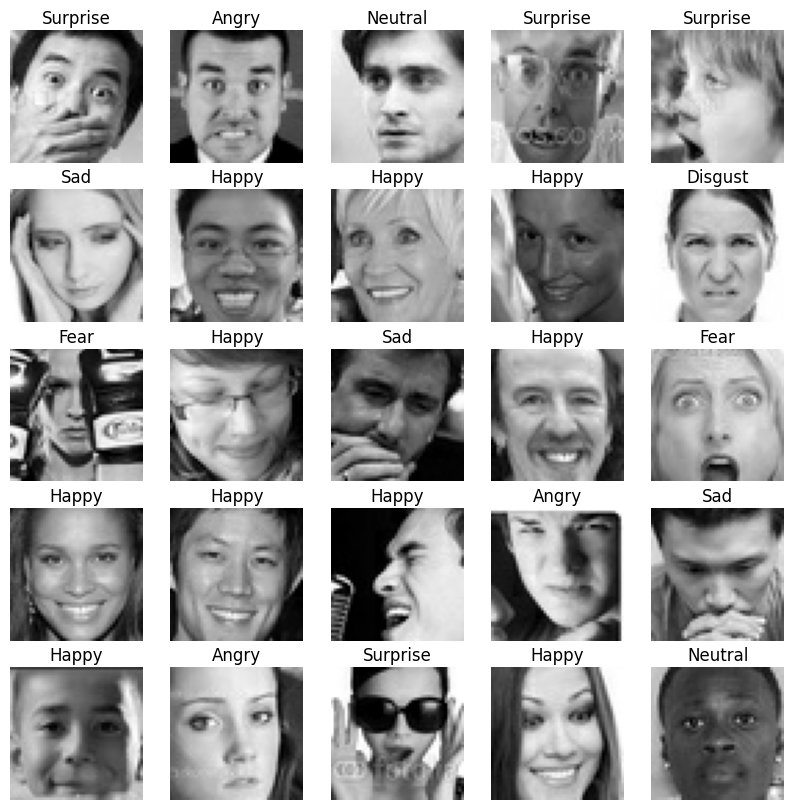

In [14]:
plt.figure(figsize=(10, 10))
for img, labels in train_data.take(5):
    for i in range(25):
        ax = plt.subplot(5, 5, i+1)
        plt.imshow(img[i].numpy().astype("uint8"), cmap='gray')
        label = tf.argmax(labels[i]).numpy()
        plt.title(label=f'{EMOTIONS_CLASSES[label].capitalize()}',
                  pad=5)
        plt.axis("off")